# Полный standalone pipeline курсовой работы

Тема: **классификация новостных текстов по тематике с использованием методов семантического анализа и ансамблевых моделей**.

Этот ноутбук сделан как самодостаточная версия практической части: он не импортирует `src/` и содержит весь код прямо в ячейках. Для запуска нужны только датасет `data/raw/train.csv` и библиотеки из окружения проекта.

Зафиксированные параметры соответствуют итоговым экспериментам курсовой:

- `TF-IDF + Logistic Regression`: `max_features=10000`, `ngram_range=(1, 2)`, `C=1.0`, `max_iter=1000`.
- `CNN`: `epochs=5`, `batch_size=256`, `embedding_dim=200`, `max_length=80`, `learning_rate=1e-3`, `kernel_sizes=[2, 3, 4]`, `dropout=0.3`.
- `DistilBERT`: `distilbert-base-uncased`, `epochs=3`, `batch_size=16`, `gradient_accumulation_steps=2`, `learning_rate=2e-5`, `max_length=128`.
- `Stacking + Optuna`: `C=0.02149242841367785`, `solver='lbfgs'`, `max_iter=1291`.

## 0. Импорты и настройки

In [1]:
from __future__ import annotations

import html
import json
import os
import random
import re
import sys
import time
from collections import Counter
from datetime import datetime
from pathlib import Path

# Runtime caches stay near the notebook/project instead of user home directories.
_initial_cwd = Path.cwd().resolve()
_cache_root = _initial_cwd if _initial_cwd.name != 'notebooks' else _initial_cwd.parent
os.environ.setdefault('MPLCONFIGDIR', str(_cache_root / '.matplotlib'))
os.environ.setdefault('JUPYTER_CONFIG_DIR', str(_cache_root / '.jupyter'))
os.environ.setdefault('JUPYTER_DATA_DIR', str(_cache_root / '.jupyter_data'))
os.environ.setdefault('JUPYTER_RUNTIME_DIR', str(_cache_root / '.jupyter_runtime'))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

try:
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
except ImportError as exc:
    raise ImportError('Для BERT-блока нужны transformers. Установите зависимости из requirements.txt.') from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / 'curs work').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'curs work'

USE_GPU = torch.cuda.is_available()
DEVICE = torch.device('cuda' if USE_GPU else 'cpu')
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'notebook_full_pipeline'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'ARTIFACT_DIR: {ARTIFACT_DIR}')
print(f'DEVICE: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\curs\src\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\curs\src
ARTIFACT_DIR: C:\curs\src\artifacts\notebook_full_pipeline
DEVICE: cuda
GPU: NVIDIA GeForce RTX 2060


## 1. Параметры экспериментов

In [2]:
TFIDF_CONFIG = {
    'max_features': 10000,
    'ngram_range': (1, 2),
    'min_df': 2,
    'max_df': 0.95,
}

LOGREG_CONFIG = {
    'C': 1.0,
    'max_iter': 1000,
    'random_state': SEED,
}

CNN_CONFIG = {
    'epochs': 5,
    'batch_size': 256,
    'embedding_dim': 200,
    'max_length': 80,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'dropout': 0.3,
    'num_filters': 128,
    'kernel_sizes': [2, 3, 4],
    'min_freq': 2,
    'eval_batch_size': 512,
}

BERT_CONFIG = {
    'model_name': 'distilbert-base-uncased',
    'num_labels': 4,
    'max_length': 128,
    'learning_rate': 2e-5,
    'batch_size': 16,
    'epochs': 3,
    'warmup_steps': 500,
    'weight_decay': 0.01,
    'gradient_accumulation_steps': 2,
    'max_grad_norm': 1.0,
    'eval_batch_size': 16,
    'mixed_precision': USE_GPU,
}

STACKING_OPTUNA_PARAMS = {
    'C': 0.02149242841367785,
    'solver': 'lbfgs',
    'max_iter': 1291,
    'random_state': SEED,
}

TARGETS = {'accuracy': 0.90, 'f1_macro': 0.88}

pd.DataFrame([
    {'model': 'TF-IDF + Logistic Regression', **TFIDF_CONFIG, **LOGREG_CONFIG},
    {'model': 'CNN', **CNN_CONFIG},
    {'model': 'DistilBERT', **BERT_CONFIG},
    {'model': 'Stacking + Optuna', **STACKING_OPTUNA_PARAMS},
])

,model,max_features,ngram_range,min_df,max_df,C,max_iter,random_state,epochs,batch_size,embedding_dim,max_length,learning_rate,weight_decay,dropout,num_filters,kernel_sizes,min_freq,eval_batch_size,model_name,num_labels,warmup_steps,gradient_accumulation_steps,max_grad_norm,mixed_precision,solver
0,TF-IDF + Logistic Regression,10000.0,"(1, 2)",2.0,0.95,1.000000,1000.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,256.0,200.0,80.0,0.00100,0.00001,0.3,128.0,"[2, 3, 4]",2.0,512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DistilBERT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,16.0,NaN,128.0,0.00002,0.01000,NaN,NaN,NaN,NaN,16.0,distilbert-base-uncased,4.0,500.0,2.0,1.0,True,NaN
3,Stacking + Optuna,NaN,NaN,NaN,NaN,0.021492,1291.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lbfgs


## 2. Загрузка данных

Ожидаемый файл: `data/raw/train.csv`. В текущем проекте текст хранится в колонке `title`, а класс - в `class_name`.

In [4]:
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'train.csv'
assert DATA_PATH.exists(), f'Не найден файл данных: {DATA_PATH}'

df = pd.read_csv(DATA_PATH)

if 'title' in df.columns and 'description' in df.columns:
    df['text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')
elif 'title' in df.columns:
    df['text'] = df['title'].fillna('')
elif 'text' not in df.columns:
    raise ValueError('В датасете должна быть колонка title, description или text')

if 'class_name' in df.columns:
    df['class'] = df['class_name']
elif 'class' not in df.columns and 'class_index' in df.columns:
    df['class'] = df['class_index'].astype(str)

print(f'Количество записей: {len(df):,}')
print(f'Колонки: {df.columns.tolist()}')
df.head()

Количество записей: 120,000
Колонки: ['class_index', 'title', 'class_name', 'text', 'class']


,class_index,title,class_name,text,class
0,2,Wall St. Bears Claw Back Into the Black (Reute...,Business,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,2,"Oil prices soar to all-time record, posing new...",Business,"Oil prices soar to all-time record, posing new...",Business


## 3. Предварительный анализ данных

In [5]:
text_lengths_chars = df['text'].astype(str).str.len()
text_lengths_words = df['text'].astype(str).str.split().str.len()

eda_summary = {
    'num_rows': int(len(df)),
    'num_classes': int(df['class'].nunique()),
    'missing_text': int(df['text'].isna().sum()),
    'missing_class': int(df['class'].isna().sum()),
    'duplicates': int(df.duplicated(subset=['text', 'class']).sum()),
    'mean_chars': float(text_lengths_chars.mean()),
    'median_chars': float(text_lengths_chars.median()),
    'min_chars': int(text_lengths_chars.min()),
    'max_chars': int(text_lengths_chars.max()),
    'mean_words': float(text_lengths_words.mean()),
    'median_words': float(text_lengths_words.median()),
    'min_words': int(text_lengths_words.min()),
    'max_words': int(text_lengths_words.max()),
}

with open(ARTIFACT_DIR / 'eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)

pd.Series(eda_summary).to_frame('value')

,value
num_rows,120000.000000
num_classes,4.000000
missing_text,0.000000
missing_class,0.000000
duplicates,0.000000
mean_chars,236.477525
median_chars,232.000000
min_chars,100.000000
max_chars,1012.000000
mean_words,37.847450


In [6]:
class_counts = df['class'].value_counts().sort_index()
class_distribution = pd.DataFrame({
    'class': class_counts.index,
    'count': class_counts.values,
    'share': class_counts.values / len(df),
})
class_distribution

,class,count,share
0,Business,30000,0.25
1,Sci/Tech,30000,0.25
2,Sports,30000,0.25
3,World,30000,0.25


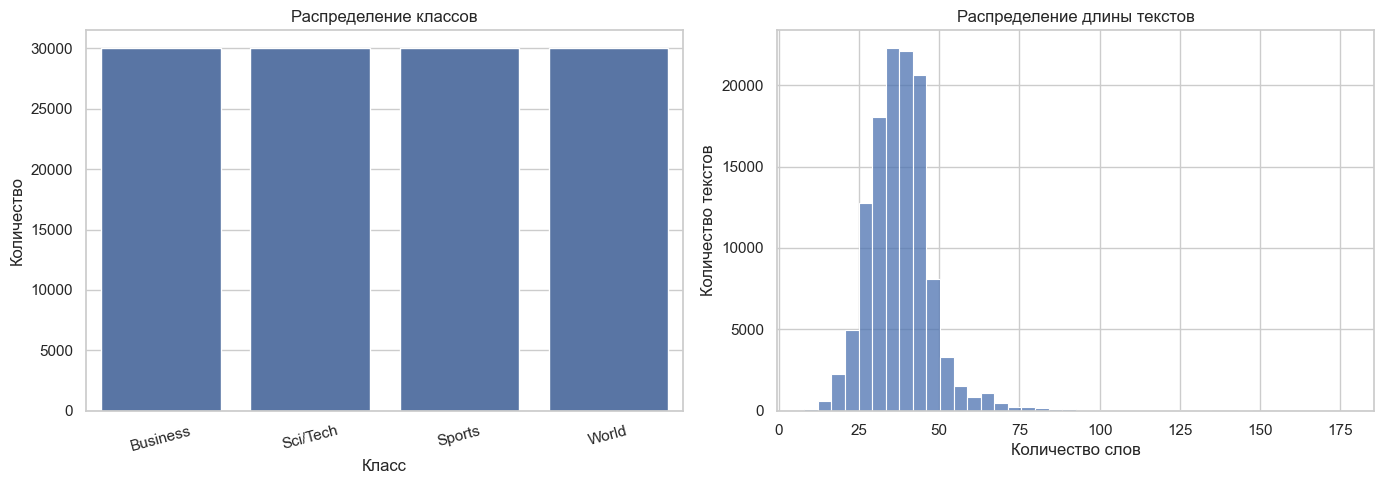

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=class_distribution, x='class', y='count', ax=axes[0])
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=15)

sns.histplot(text_lengths_words, bins=40, ax=axes[1])
axes[1].set_title('Распределение длины текстов')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Количество текстов')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_class_length_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Предобработка текста

Для классических моделей и CNN используется более выраженная очистка: удаление HTML, URL, email, лишних символов, нижний регистр и стоп-слова. Для BERT используется минимальная очистка, чтобы сохранить естественный контекст.

In [8]:
BASIC_STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'while', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'to', 'of', 'in', 'on', 'for', 'with', 'as', 'by', 'at',
    'from', 'that', 'this', 'it', 'its', 'into', 'about', 'after', 'before', 'over',
    'under', 'new', 'reuters', 'ap', 'afp'
}

try:
    from nltk.stem import WordNetLemmatizer
    _lemmatizer = WordNetLemmatizer()
except Exception:
    _lemmatizer = None


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s\.!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_classic(text: str) -> str:
    text = clean_text(text).lower()
    tokens = re.findall(r'[a-z]+', text)
    tokens = [t for t in tokens if t not in BASIC_STOPWORDS and len(t) > 1]
    if _lemmatizer is not None:
        try:
            tokens = [_lemmatizer.lemmatize(t) for t in tokens]
        except LookupError:
            # If WordNet data is unavailable, keep the notebook runnable without downloads.
            pass
    return ' '.join(tokens)


def preprocess_bert(text: str) -> str:
    return clean_text(text)

start = time.time()
df['text_classic'] = [preprocess_classic(t) for t in df['text'].astype(str)]
df['text_bert'] = [preprocess_bert(t) for t in df['text'].astype(str)]
print(f'Предобработка завершена за {(time.time() - start) / 60:.2f} мин')

df[['text', 'text_classic', 'text_bert', 'class']].head()

Предобработка завершена за 0.12 мин


,text,text_classic,text_bert,class
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back black short sellers wa...,Wall St. Bears Claw Back Into the Black Reuter...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace priv...,Carlyle Looks Toward Commercial Aerospace Reut...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stocks outlook soaring crude...,Oil and Economy Cloud Stocks Outlook Reuters R...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports main southern pipeline ...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",oil prices soar all time record posing menace ...,Oil prices soar to all time record posing new ...,Business


## 5. Train / validation / test split

Используется стратифицированное разбиение **70/15/15**.

In [9]:
idx = np.arange(len(df))
y = df['class']

train_idx, temp_idx, y_train, y_temp = train_test_split(
    idx, y, test_size=0.30, stratify=y, random_state=SEED
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

X_train_classic = df['text_classic'].iloc[train_idx].reset_index(drop=True)
X_val_classic = df['text_classic'].iloc[val_idx].reset_index(drop=True)
X_test_classic = df['text_classic'].iloc[test_idx].reset_index(drop=True)

X_train_bert = df['text_bert'].iloc[train_idx].reset_index(drop=True)
X_val_bert = df['text_bert'].iloc[val_idx].reset_index(drop=True)
X_test_bert = df['text_bert'].iloc[test_idx].reset_index(drop=True)

y_train = y.iloc[train_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
class_names = sorted(y.unique())

split_table = pd.DataFrame([
    {'split': 'train', 'count': len(y_train)},
    {'split': 'validation', 'count': len(y_val)},
    {'split': 'test', 'count': len(y_test)},
])
print(split_table)

pd.crosstab(
    pd.Series(['train'] * len(y_train) + ['validation'] * len(y_val) + ['test'] * len(y_test), name='split'),
    pd.concat([y_train, y_val, y_test], ignore_index=True),
)

        split  count
0       train  84000
1  validation  18000
2        test  18000


class,Business,Sci/Tech,Sports,World
split,,,,
test,4500,4500,4500,4500
train,21000,21000,21000,21000
validation,4500,4500,4500,4500


In [10]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
pd.DataFrame({'text': X_train_classic, 'text_bert': X_train_bert, 'class': y_train}).to_csv(processed_dir / 'train_split.csv', index=False)
pd.DataFrame({'text': X_val_classic, 'text_bert': X_val_bert, 'class': y_val}).to_csv(processed_dir / 'val_split.csv', index=False)
pd.DataFrame({'text': X_test_classic, 'text_bert': X_test_bert, 'class': y_test}).to_csv(processed_dir / 'test_split.csv', index=False)
print(f'Splits сохранены в {processed_dir}')

Splits сохранены в C:\curs\src\data\processed


## 6. Вспомогательные функции оценки

In [11]:
all_metrics = []
predictions_cache = {}
probas_cache = {}


def evaluate_predictions(model_name: str, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    metrics = {
        'model': model_name,
        'accuracy': float(accuracy),
        'precision_macro': float(precision),
        'recall_macro': float(recall),
        'f1_macro': float(f1),
    }
    all_metrics.append(metrics)
    predictions_cache[model_name] = np.array(y_pred)
    if y_proba is not None:
        probas_cache[model_name] = np.array(y_proba)

    pred_df = pd.DataFrame({'y_true': list(y_true), 'y_pred': list(y_pred)})
    if y_proba is not None:
        for i, cls in enumerate(class_names):
            pred_df[f'proba_{cls}'] = y_proba[:, i]
    pred_df.to_csv(ARTIFACT_DIR / f'{model_name}_predictions.csv', index=False)

    print(f'\n{model_name}')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'Macro-F1:  {f1:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, labels=class_names, zero_division=0))
    return metrics


def plot_confusion(y_true, y_pred, title: str, filename: str):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()
    return cm

## 7. Baseline: TF-IDF + Logistic Regression

Время обучения TF-IDF + LogReg: 0.20 мин
Validation Accuracy: 0.9087

tfidf_logreg
Accuracy:  0.9075
Precision: 0.9072
Recall:    0.9075
Macro-F1:  0.9073

Classification report:
              precision    recall  f1-score   support

    Business       0.88      0.87      0.88      4500
    Sci/Tech       0.88      0.88      0.88      4500
      Sports       0.95      0.98      0.96      4500
       World       0.92      0.90      0.91      4500

    accuracy                           0.91     18000
   macro avg       0.91      0.91      0.91     18000
weighted avg       0.91      0.91      0.91     18000



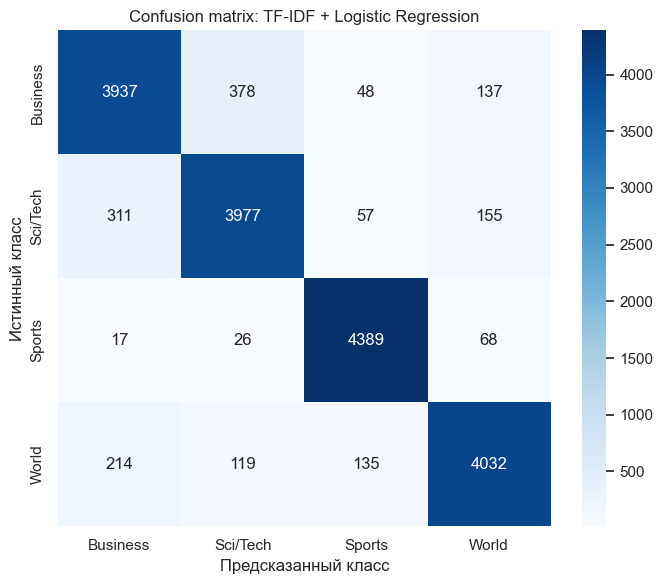

array([[3937,  378,   48,  137],
       [ 311, 3977,   57,  155],
       [  17,   26, 4389,   68],
       [ 214,  119,  135, 4032]])

In [12]:
tfidf_logreg = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_CONFIG)),
    ('clf', LogisticRegression(**LOGREG_CONFIG)),
])

start = time.time()
tfidf_logreg.fit(X_train_classic, y_train)
print(f'Время обучения TF-IDF + LogReg: {(time.time() - start) / 60:.2f} мин')
print(f'Validation Accuracy: {accuracy_score(y_val, tfidf_logreg.predict(X_val_classic)):.4f}')

tfidf_pred = tfidf_logreg.predict(X_test_classic)
tfidf_proba = tfidf_logreg.predict_proba(X_test_classic)
evaluate_predictions('tfidf_logreg', y_test, tfidf_pred, tfidf_proba)
plot_confusion(y_test, tfidf_pred, 'Confusion matrix: TF-IDF + Logistic Regression', 'cm_tfidf_logreg.png')

## 8. CNN с Word2Vec-style embeddings

Epoch 1/5 | Loss: 0.6058 | Acc: 0.7761
Epoch 2/5 | Loss: 0.3554 | Acc: 0.8799
Epoch 3/5 | Loss: 0.2859 | Acc: 0.9040
Epoch 4/5 | Loss: 0.2399 | Acc: 0.9196
Epoch 5/5 | Loss: 0.2017 | Acc: 0.9314
Время обучения CNN: 1.60 мин
Validation Accuracy: 0.8986

cnn
Accuracy:  0.9004
Precision: 0.9006
Recall:    0.9004
Macro-F1:  0.9003

Classification report:
              precision    recall  f1-score   support

    Business       0.87      0.87      0.87      4500
    Sci/Tech       0.87      0.89      0.88      4500
      Sports       0.95      0.97      0.96      4500
       World       0.92      0.88      0.90      4500

    accuracy                           0.90     18000
   macro avg       0.90      0.90      0.90     18000
weighted avg       0.90      0.90      0.90     18000



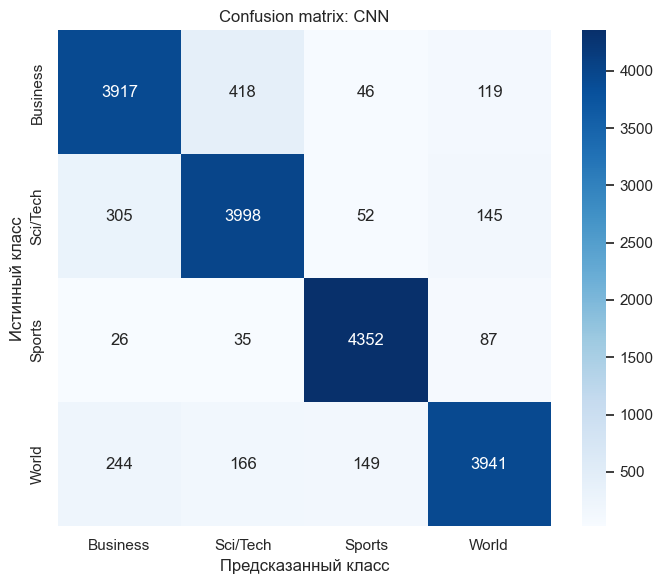

array([[3917,  418,   46,  119],
       [ 305, 3998,   52,  145],
       [  26,   35, 4352,   87],
       [ 244,  166,  149, 3941]])

In [13]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters, kernel_sizes, dropout, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            pooled.append(torch.max(c, dim=2).values)
        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        return self.fc(x)


def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    word_to_idx = {'<pad>': 0, '<unk>': 1}
    for token, freq in counter.items():
        if freq >= min_freq and token not in word_to_idx:
            word_to_idx[token] = len(word_to_idx)
    return word_to_idx


def encode_texts(texts, word_to_idx, max_length):
    encoded = np.zeros((len(texts), max_length), dtype=np.int64)
    unk = word_to_idx['<unk>']
    for i, text in enumerate(texts):
        ids = [word_to_idx.get(tok, unk) for tok in str(text).split()[:max_length]]
        if ids:
            encoded[i, :len(ids)] = ids
    return encoded


def make_loader(X_encoded, y_encoded=None, batch_size=256, shuffle=False):
    x_tensor = torch.from_numpy(X_encoded)
    if y_encoded is None:
        return DataLoader(x_tensor, batch_size=batch_size, shuffle=shuffle)
    y_tensor = torch.from_numpy(y_encoded)
    return DataLoader(TensorDataset(x_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

label_to_id = {label: i for i, label in enumerate(class_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

word_to_idx = build_vocab(X_train_classic, min_freq=CNN_CONFIG['min_freq'])
X_train_cnn = encode_texts(X_train_classic, word_to_idx, CNN_CONFIG['max_length'])
X_val_cnn = encode_texts(X_val_classic, word_to_idx, CNN_CONFIG['max_length'])
X_test_cnn = encode_texts(X_test_classic, word_to_idx, CNN_CONFIG['max_length'])
y_train_cnn = np.array([label_to_id[v] for v in y_train], dtype=np.int64)
y_val_cnn = np.array([label_to_id[v] for v in y_val], dtype=np.int64)

cnn_model = TextCNN(
    vocab_size=len(word_to_idx),
    embedding_dim=CNN_CONFIG['embedding_dim'],
    num_classes=len(class_names),
    num_filters=CNN_CONFIG['num_filters'],
    kernel_sizes=CNN_CONFIG['kernel_sizes'],
    dropout=CNN_CONFIG['dropout'],
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=CNN_CONFIG['learning_rate'],
    weight_decay=CNN_CONFIG['weight_decay'],
)

train_loader = make_loader(X_train_cnn, y_train_cnn, batch_size=CNN_CONFIG['batch_size'], shuffle=True)

start = time.time()
cnn_history = []
for epoch in range(CNN_CONFIG['epochs']):
    cnn_model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        optimizer.zero_grad()
        logits = cnn_model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        total_correct += (torch.argmax(logits, dim=1) == batch_y).sum().item()
        total_seen += batch_x.size(0)

    epoch_loss = total_loss / total_seen
    epoch_acc = total_correct / total_seen
    cnn_history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'accuracy': epoch_acc})
    print(f"Epoch {epoch + 1}/{CNN_CONFIG['epochs']} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

print(f'Время обучения CNN: {(time.time() - start) / 60:.2f} мин')


def cnn_predict_proba(X_encoded):
    cnn_model.eval()
    loader = make_loader(X_encoded, batch_size=CNN_CONFIG['eval_batch_size'], shuffle=False)
    out = []
    with torch.no_grad():
        for batch_x in loader:
            logits = cnn_model(batch_x.to(DEVICE))
            out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(out)

cnn_val_proba = cnn_predict_proba(X_val_cnn)
cnn_val_pred = np.array([id_to_label[i] for i in np.argmax(cnn_val_proba, axis=1)])
print(f'Validation Accuracy: {accuracy_score(y_val, cnn_val_pred):.4f}')

cnn_proba = cnn_predict_proba(X_test_cnn)
cnn_pred = np.array([id_to_label[i] for i in np.argmax(cnn_proba, axis=1)])
evaluate_predictions('cnn', y_test, cnn_pred, cnn_proba)
plot_confusion(y_test, cnn_pred, 'Confusion matrix: CNN', 'cm_cnn.png')

## 9. DistilBERT

In [14]:
tokenizer = AutoTokenizer.from_pretrained(BERT_CONFIG['model_name'])
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CONFIG['model_name'],
    num_labels=len(class_names),
    attn_implementation='eager',
).to(DEVICE)

bert_label_to_id = {label: i for i, label in enumerate(class_names)}
bert_id_to_label = {i: label for label, i in bert_label_to_id.items()}

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=BERT_CONFIG['max_length'],
        return_tensors='pt',
    )

train_enc = tokenize_texts(X_train_bert)
train_labels = torch.tensor([bert_label_to_id[v] for v in y_train], dtype=torch.long)
train_dataset = TensorDataset(train_enc['input_ids'], train_enc['attention_mask'], train_labels)
train_loader = DataLoader(train_dataset, batch_size=BERT_CONFIG['batch_size'], shuffle=True)

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in bert_model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': BERT_CONFIG['weight_decay'],
    },
    {
        'params': [p for n, p in bert_model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=BERT_CONFIG['learning_rate'])

total_steps = len(train_loader) * BERT_CONFIG['epochs'] // BERT_CONFIG['gradient_accumulation_steps']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=BERT_CONFIG['warmup_steps'],
    num_training_steps=max(total_steps, 1),
)
scaler = torch.cuda.amp.GradScaler() if BERT_CONFIG['mixed_precision'] else None

start = time.time()
bert_history = []
global_step = 0
optimizer.zero_grad()

for epoch in range(BERT_CONFIG['epochs']):
    bert_model.train()
    epoch_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]
        with torch.cuda.amp.autocast(enabled=scaler is not None):
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / BERT_CONFIG['gradient_accumulation_steps']

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (batch_idx + 1) % BERT_CONFIG['gradient_accumulation_steps'] == 0:
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(bert_model.parameters(), BERT_CONFIG['max_grad_norm'])
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(bert_model.parameters(), BERT_CONFIG['max_grad_norm'])
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        epoch_loss += loss.item() * BERT_CONFIG['gradient_accumulation_steps']
        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch {epoch + 1}/{BERT_CONFIG['epochs']} | Batch {batch_idx + 1}/{len(train_loader)} | Loss: {epoch_loss / (batch_idx + 1):.4f}")

    avg_loss = epoch_loss / len(train_loader)
    bert_history.append({'epoch': epoch + 1, 'loss': avg_loss})
    print(f"Epoch {epoch + 1}/{BERT_CONFIG['epochs']} завершена | Loss: {avg_loss:.4f}")

print(f'Время обучения DistilBERT: {(time.time() - start) / 60:.2f} мин')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4439.92it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\artle\AppData\Local\Temp\ipykernel_4280\3766374395.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torc

Epoch 1/3 | Batch 50/5250 | Loss: 1.3788
Epoch 1/3 | Batch 100/5250 | Loss: 1.3751
Epoch 1/3 | Batch 150/5250 | Loss: 1.3644
Epoch 1/3 | Batch 200/5250 | Loss: 1.3421
Epoch 1/3 | Batch 250/5250 | Loss: 1.2979
Epoch 1/3 | Batch 300/5250 | Loss: 1.2268
Epoch 1/3 | Batch 350/5250 | Loss: 1.1421
Epoch 1/3 | Batch 400/5250 | Loss: 1.0612
Epoch 1/3 | Batch 450/5250 | Loss: 0.9861
Epoch 1/3 | Batch 500/5250 | Loss: 0.9276
Epoch 1/3 | Batch 550/5250 | Loss: 0.8780
Epoch 1/3 | Batch 600/5250 | Loss: 0.8368
Epoch 1/3 | Batch 650/5250 | Loss: 0.7967
Epoch 1/3 | Batch 700/5250 | Loss: 0.7656
Epoch 1/3 | Batch 750/5250 | Loss: 0.7375
Epoch 1/3 | Batch 800/5250 | Loss: 0.7127
Epoch 1/3 | Batch 850/5250 | Loss: 0.6887
Epoch 1/3 | Batch 900/5250 | Loss: 0.6677
Epoch 1/3 | Batch 950/5250 | Loss: 0.6495
Epoch 1/3 | Batch 1000/5250 | Loss: 0.6328
Epoch 1/3 | Batch 1050/5250 | Loss: 0.6186
Epoch 1/3 | Batch 1100/5250 | Loss: 0.6034
Epoch 1/3 | Batch 1150/5250 | Loss: 0.5916
Epoch 1/3 | Batch 1200/5250 | L

C:\Users\artle\AppData\Local\Temp\ipykernel_4280\3727852790.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Validation Accuracy: 0.9396


C:\Users\artle\AppData\Local\Temp\ipykernel_4280\3727852790.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):



bert_distilbert
Accuracy:  0.9408
Precision: 0.9410
Recall:    0.9408
Macro-F1:  0.9408

Classification report:
              precision    recall  f1-score   support

    Business       0.92      0.91      0.91      4500
    Sci/Tech       0.91      0.93      0.92      4500
      Sports       0.99      0.99      0.99      4500
       World       0.96      0.94      0.95      4500

    accuracy                           0.94     18000
   macro avg       0.94      0.94      0.94     18000
weighted avg       0.94      0.94      0.94     18000



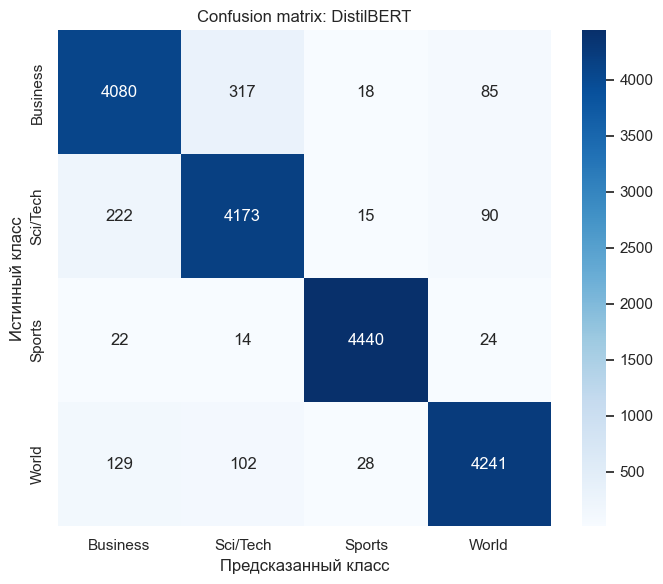

array([[4080,  317,   18,   85],
       [ 222, 4173,   15,   90],
       [  22,   14, 4440,   24],
       [ 129,  102,   28, 4241]])

In [15]:
def bert_predict_proba(texts):
    bert_model.eval()
    texts = list(texts)
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), BERT_CONFIG['eval_batch_size']):
            batch_texts = texts[i:i + BERT_CONFIG['eval_batch_size']]
            enc = tokenize_texts(batch_texts)
            input_ids = enc['input_ids'].to(DEVICE)
            attention_mask = enc['attention_mask'].to(DEVICE)
            with torch.cuda.amp.autocast(enabled=scaler is not None):
                logits = bert_model(input_ids=input_ids, attention_mask=attention_mask).logits
            out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(out)

bert_val_proba = bert_predict_proba(X_val_bert)
bert_val_pred = np.array([bert_id_to_label[i] for i in np.argmax(bert_val_proba, axis=1)])
print(f'Validation Accuracy: {accuracy_score(y_val, bert_val_pred):.4f}')

bert_proba = bert_predict_proba(X_test_bert)
bert_pred = np.array([bert_id_to_label[i] for i in np.argmax(bert_proba, axis=1)])
evaluate_predictions('bert_distilbert', y_test, bert_pred, bert_proba)
plot_confusion(y_test, bert_pred, 'Confusion matrix: DistilBERT', 'cm_bert.png')

## 10. Voting ensemble


voting
Accuracy:  0.9181
Precision: 0.9181
Recall:    0.9181
Macro-F1:  0.9180

Classification report:
              precision    recall  f1-score   support

    Business       0.89      0.89      0.89      4500
    Sci/Tech       0.89      0.90      0.90      4500
      Sports       0.96      0.98      0.97      4500
       World       0.94      0.90      0.92      4500

    accuracy                           0.92     18000
   macro avg       0.92      0.92      0.92     18000
weighted avg       0.92      0.92      0.92     18000



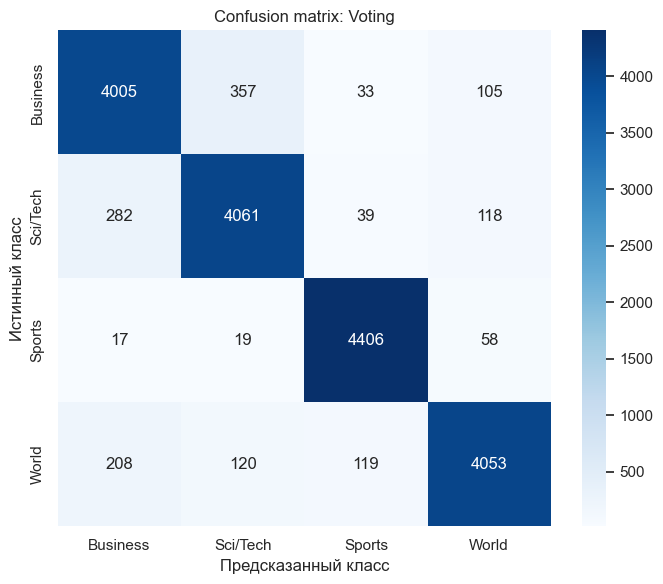

array([[4005,  357,   33,  105],
       [ 282, 4061,   39,  118],
       [  17,   19, 4406,   58],
       [ 208,  120,  119, 4053]])

In [16]:
base_predictions = np.vstack([tfidf_pred, cnn_pred, bert_pred]).T
voting_pred = []
for row in base_predictions:
    values, counts = np.unique(row, return_counts=True)
    voting_pred.append(values[np.argmax(counts)])
voting_pred = np.array(voting_pred)

evaluate_predictions('voting', y_test, voting_pred, None)
plot_confusion(y_test, voting_pred, 'Confusion matrix: Voting', 'cm_voting.png')

## 11. Stacking ensemble

Мета-модель обучается на вероятностях базовых моделей на validation-выборке. Test используется только для финальной оценки.


stacking
Accuracy:  0.9428
Precision: 0.9430
Recall:    0.9428
Macro-F1:  0.9429

Classification report:
              precision    recall  f1-score   support

    Business       0.92      0.91      0.91      4500
    Sci/Tech       0.91      0.93      0.92      4500
      Sports       0.99      0.99      0.99      4500
       World       0.96      0.94      0.95      4500

    accuracy                           0.94     18000
   macro avg       0.94      0.94      0.94     18000
weighted avg       0.94      0.94      0.94     18000



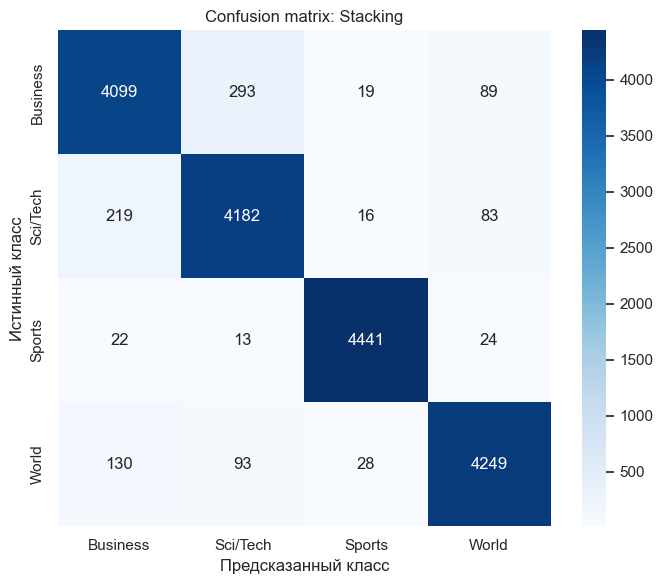

array([[4099,  293,   19,   89],
       [ 219, 4182,   16,   83],
       [  22,   13, 4441,   24],
       [ 130,   93,   28, 4249]])

In [17]:
tfidf_val_proba = tfidf_logreg.predict_proba(X_val_classic)
# cnn_val_proba and bert_val_proba were computed above.

meta_X_val = np.hstack([tfidf_val_proba, cnn_val_proba, bert_val_proba])
meta_y_val = y_val.to_numpy()
meta_X_test = np.hstack([tfidf_proba, cnn_proba, bert_proba])

stacking_model = LogisticRegression(max_iter=1000, random_state=SEED)
stacking_model.fit(meta_X_val, meta_y_val)
stacking_pred = stacking_model.predict(meta_X_test)
stacking_proba = stacking_model.predict_proba(meta_X_test)

evaluate_predictions('stacking', y_test, stacking_pred, stacking_proba)
plot_confusion(y_test, stacking_pred, 'Confusion matrix: Stacking', 'cm_stacking.png')

## 12. Stacking + Optuna-параметры


stacking_optuna_params
Accuracy:  0.9424
Precision: 0.9425
Recall:    0.9424
Macro-F1:  0.9425

Classification report:
              precision    recall  f1-score   support

    Business       0.92      0.91      0.91      4500
    Sci/Tech       0.91      0.93      0.92      4500
      Sports       0.98      0.99      0.99      4500
       World       0.96      0.94      0.95      4500

    accuracy                           0.94     18000
   macro avg       0.94      0.94      0.94     18000
weighted avg       0.94      0.94      0.94     18000



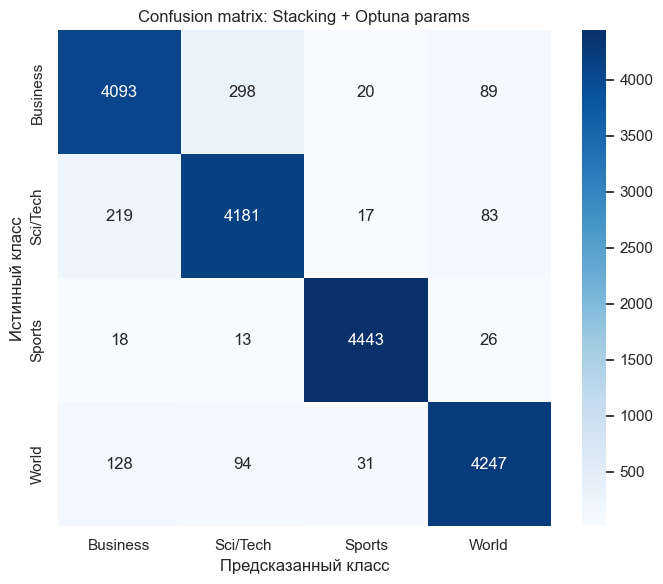

array([[4093,  298,   20,   89],
       [ 219, 4181,   17,   83],
       [  18,   13, 4443,   26],
       [ 128,   94,   31, 4247]])

In [18]:
stacking_optuna_model = LogisticRegression(**STACKING_OPTUNA_PARAMS)
stacking_optuna_model.fit(meta_X_val, meta_y_val)
stacking_optuna_pred = stacking_optuna_model.predict(meta_X_test)
stacking_optuna_proba = stacking_optuna_model.predict_proba(meta_X_test)

evaluate_predictions('stacking_optuna_params', y_test, stacking_optuna_pred, stacking_optuna_proba)
plot_confusion(y_test, stacking_optuna_pred, 'Confusion matrix: Stacking + Optuna params', 'cm_stacking_optuna.png')

### 12.1. Опциональный повтор Optuna search

По умолчанию отключено, потому что параметры итогового эксперимента уже зафиксированы. Если нужно заново выполнить 30 trials, поставьте `RUN_OPTUNA_SEARCH = True`.

In [19]:
RUN_OPTUNA_SEARCH = False

if RUN_OPTUNA_SEARCH:
    import optuna

    meta_train_X, meta_holdout_X, meta_train_y, meta_holdout_y = train_test_split(
        meta_X_val,
        meta_y_val,
        test_size=0.30,
        stratify=meta_y_val,
        random_state=SEED,
    )

    def objective(trial):
        params = {
            'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
            'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
            'max_iter': trial.suggest_int('max_iter', 500, 2000),
            'random_state': SEED,
        }
        model = LogisticRegression(**params)
        model.fit(meta_train_X, meta_train_y)
        pred = model.predict(meta_holdout_X)
        _, _, f1, _ = precision_recall_fscore_support(meta_holdout_y, pred, average='macro', zero_division=0)
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30)
    print('Best params:', study.best_params)
    print('Best validation F1-macro:', study.best_value)
else:
    print('Optuna search пропущен. Используются зафиксированные параметры итогового эксперимента.')

Optuna search пропущен. Используются зафиксированные параметры итогового эксперимента.


## 13. Сравнение моделей

In [20]:
metrics_df = pd.DataFrame(all_metrics).sort_values('accuracy', ascending=False).reset_index(drop=True)
metrics_df.to_csv(ARTIFACT_DIR / 'model_metrics_summary.csv', index=False)
metrics_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,stacking,0.942833,0.942955,0.942833,0.942864
1,stacking_optuna_params,0.942444,0.942548,0.942444,0.942461
2,bert_distilbert,0.940778,0.940964,0.940778,0.940823
3,voting,0.918056,0.918101,0.918056,0.917960
4,tfidf_logreg,0.907500,0.907239,0.907500,0.907287
5,cnn,0.900444,0.900609,0.900444,0.900337


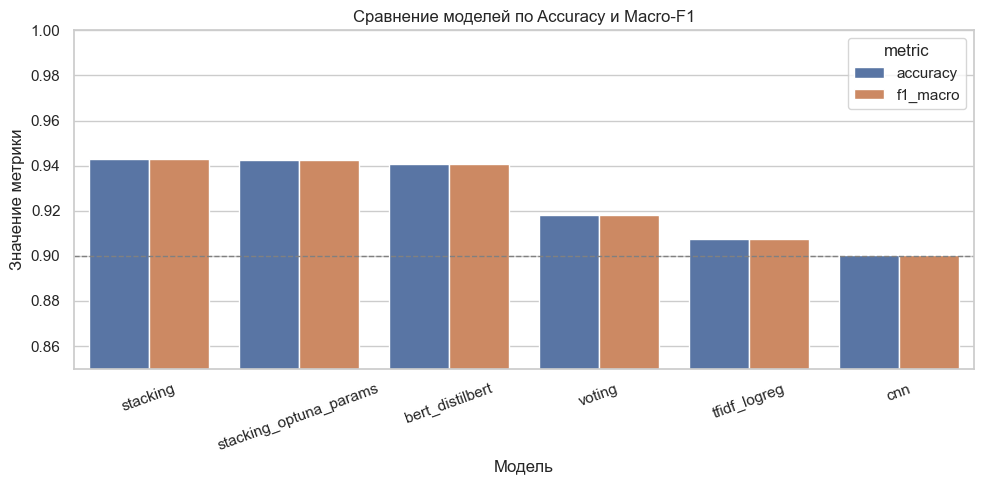

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = metrics_df.melt(id_vars='model', value_vars=['accuracy', 'f1_macro'], var_name='metric', value_name='value')
sns.barplot(data=plot_df, x='model', y='value', hue='metric', ax=ax)
ax.axhline(TARGETS['accuracy'], linestyle='--', color='gray', linewidth=1, label='Accuracy target')
ax.set_ylim(0.85, 1.0)
ax.set_title('Сравнение моделей по Accuracy и Macro-F1')
ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'models_accuracy_f1_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 14. t-SNE визуализация DistilBERT-эмбеддингов

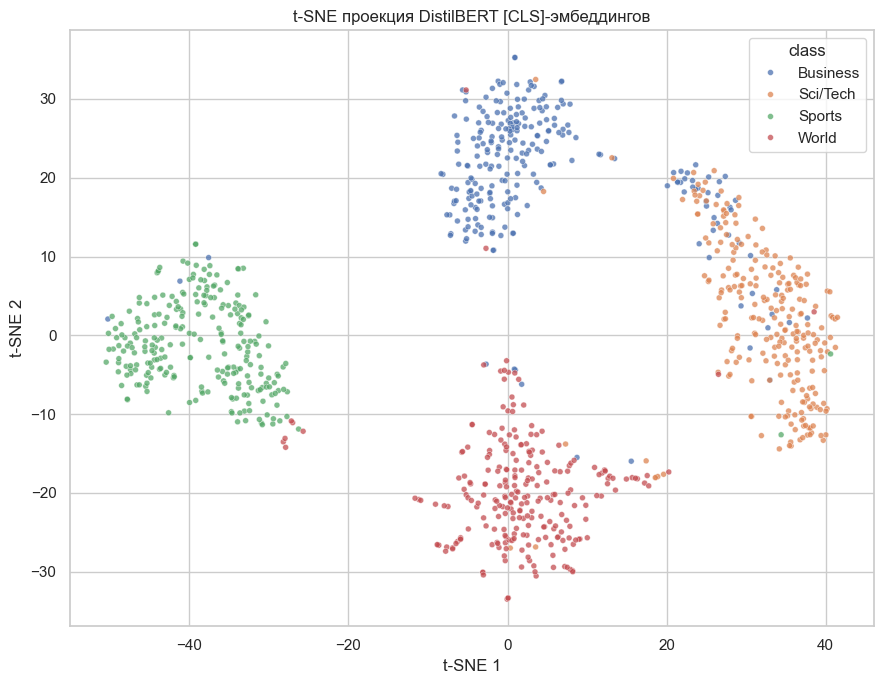

In [22]:
def get_distilbert_cls_embeddings(texts, batch_size=64):
    bert_model.eval()
    texts = list(texts)
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenize_texts(texts[i:i + batch_size])
            input_ids = enc['input_ids'].to(DEVICE)
            attention_mask = enc['attention_mask'].to(DEVICE)
            outputs = bert_model.distilbert(input_ids=input_ids, attention_mask=attention_mask)
            embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeddings)

tsne_source = pd.DataFrame({'text': X_test_bert, 'class': y_test}).reset_index(drop=True)
tsne_sample = pd.concat(
    [group.sample(n=min(250, len(group)), random_state=SEED) for _, group in tsne_source.groupby('class')],
    ignore_index=True,
)

embeddings = get_distilbert_cls_embeddings(tsne_sample['text'], batch_size=64 if USE_GPU else 16)
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=SEED)
coords = tsne.fit_transform(embeddings)

tsne_df = pd.DataFrame({'x': coords[:, 0], 'y': coords[:, 1], 'class': tsne_sample['class']})
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x='x', y='y', hue='class', s=18, alpha=0.75, ax=ax)
ax.set_title('t-SNE проекция DistilBERT [CLS]-эмбеддингов')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'tsne_bert_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()

## 15. Attention heatmap DistilBERT

Example text: Terror Bombings Hit Egypt A total of people were killed in Thursday night s Oct terror attacks on two Sinai holiday resorts frequented by Israelis at the Taba Hilton and three at Ras a Satan.


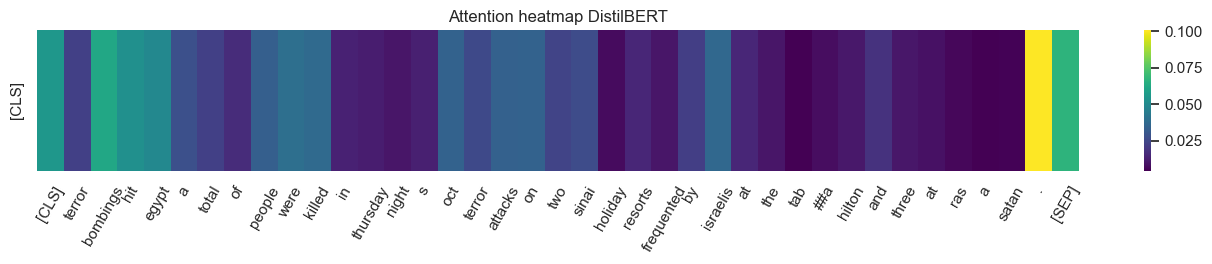

(['[CLS]',
  'terror',
  'bombings',
  'hit',
  'egypt',
  'a',
  'total',
  'of',
  'people',
  'were',
  'killed',
  'in',
  'thursday',
  'night',
  's',
  'oct',
  'terror',
  'attacks',
  'on',
  'two',
  'sinai',
  'holiday',
  'resorts',
  'frequented',
  'by',
  'israelis',
  'at',
  'the',
  'tab',
  '##a',
  'hilton',
  'and',
  'three',
  'at',
  'ras',
  'a',
  'satan',
  '.',
  '[SEP]'],
 array([0.05524135, 0.02267737, 0.06158569, 0.05231572, 0.04937646,
        0.02806623, 0.02250007, 0.01635681, 0.03314627, 0.03905115,
        0.03716279, 0.01325464, 0.01218953, 0.01002721, 0.01274364,
        0.03409528, 0.02550049, 0.03386997, 0.03426961, 0.02360334,
        0.02633493, 0.00711788, 0.01459459, 0.00977329, 0.02190134,
        0.03658978, 0.0145783 , 0.00979521, 0.00442745, 0.00746679,
        0.01059011, 0.01813511, 0.01033433, 0.0088755 , 0.00605834,
        0.00446992, 0.00500475, 0.10051233, 0.06640642], dtype=float32))

In [23]:
def plot_attention_heatmap(text: str, filename='attention_heatmap_example.png'):
    bert_model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=BERT_CONFIG['max_length'],
        return_tensors='pt',
    )
    input_ids = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)

    attention = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
    cls_attention = attention[0]
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    valid_len = int(enc['attention_mask'][0].sum().item())
    tokens = tokens[:valid_len]
    cls_attention = cls_attention[:valid_len]

    fig, ax = plt.subplots(figsize=(max(12, valid_len * 0.35), 2.8))
    sns.heatmap(cls_attention.reshape(1, -1), cmap='viridis', xticklabels=tokens, yticklabels=['[CLS]'], ax=ax)
    ax.set_title('Attention heatmap DistilBERT')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()
    return tokens, cls_attention

example_text = X_test_bert.iloc[0]
print('Example text:', example_text)
plot_attention_heatmap(example_text)

## 16. Сохранение моделей и артефактов

In [24]:
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
model_dir = PROJECT_ROOT / 'models' / 'serialized' / f'notebook_full_pipeline_{run_id}'
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(tfidf_logreg, model_dir / 'tfidf_logreg.joblib')
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'config': CNN_CONFIG,
    'word_to_idx': word_to_idx,
    'label_to_id': label_to_id,
}, model_dir / 'cnn.pt')
bert_model.save_pretrained(model_dir / 'bert')
tokenizer.save_pretrained(model_dir / 'bert')
joblib.dump(stacking_model, model_dir / 'stacking_meta_model.joblib')
joblib.dump(stacking_optuna_model, model_dir / 'stacking_optuna_meta_model.joblib')

with open(model_dir / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_df.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print(f'Модели сохранены в: {model_dir}')
print(f'Артефакты ноутбука сохранены в: {ARTIFACT_DIR}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.24it/s]

Модели сохранены в: C:\curs\src\models\serialized\notebook_full_pipeline_20260517_163628
Артефакты ноутбука сохранены в: C:\curs\src\artifacts\notebook_full_pipeline


## 17. Итоговые выводы

1. Датасет AG News сбалансирован по четырем классам, поэтому Accuracy корректно использовать как основную метрику, а Macro-F1 - как дополнительную метрику равномерного качества по классам.
2. TF-IDF + Logistic Regression является сильным baseline и показывает, что задача хорошо решается по лексическим признакам.
3. CNN учитывает локальный порядок слов и работает быстро, но в данном эксперименте уступает transformer-модели.
4. DistilBERT дает лучший результат среди одиночных моделей за счет контекстных представлений.
5. Stacking оказывается лучшим итоговым решением, потому что объединяет вероятности разнородных моделей и компенсирует часть их ошибок.
6. Optuna-параметры для мета-модели подтверждают устойчивость Stacking, но не меняют общий вывод: основной выигрыш дает ансамблирование TF-IDF, CNN и DistilBERT.